# Importações

In [83]:
pasta_dad = 'C:\\Users\\Gustavo\\OneDrive\\Documentos\\GitHub\\Labs\\AED\\Aerodinâmica de perfis\\Dados\\'
pasta_res = 'C:\\Users\\Gustavo\\OneDrive\\Documentos\\GitHub\\Labs\\AED\\Aerodinâmica de perfis\\Resultados\\'
pasta_aed = 'C:\\Users\\Gustavo\\OneDrive\\Documentos\\GitHub\\Labs\\AED\\'

In [84]:
import numpy as np
import pandas as pd
%matplotlib ipympl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import sys
from pathlib import Path
from scipy.optimize import curve_fit

sys.path.insert(0, str(Path(pasta_aed)))

from quantity import Quantity, exp, log
import aed_utils
import sensor

# Definições

### Geral

In [85]:
perfis = ['NACA_0012', 'NACA_2412', 'Placa_plana']

### Código

In [86]:
markers = ['o', 's', '^', 'D', 'v', '<', '>', '*', 'p']
markersize = 4
linewidth = 0.75
colors = ['black', 'darkolivegreen', 'royalblue', 'tan', 'orange', 'blue', 'green', 'darkgray', 'brown']
markeredgecolor = colors
markerfacecolor = 'white'
markeredgewidth = 0.75
q = 2/3
figsize_hor = (10*q, 7*q)
figsize_ver = (8*q, 10*q)
q = 1/2
figsize_hor_larger = (12*q, 6*q)
figsize_ver_larger = (12*q, 10*q)

In [87]:
idx = pd.IndexSlice

In [88]:
TO_RAD = np.pi/180
TO_DEG = 180/np.pi

### Condições exp.

In [89]:
g = 9.7685 # N/kg

rho_Ag = 997.8 # kg/m³

n_med_amostra = 3000 # Número de amostras por ponto
l_tunel = 602 # mm, largura do túnel
h_tunel = 601 # mm, altura do túnel

In [90]:
class Ar(aed_utils.Ar):

    def __init__(self, T = None, p = None):
        super().__init__(T, p)

    def read_data(self, df):

        T_0k = 273.15

        self.T = Quantity(df['T'] + T_0k, df['sigma_T'])
        self.p = Quantity(df['p'], df['sigma_p'])

        self.get_rho()
        self.get_mu_nu()


### Balança

In [91]:
class Balanca:

    def __init__(self, b):

        self.b = b
        
        self.A = sensor.Sensor()
        self.F = sensor.Sensor()
        self.D = sensor.Sensor()
    
    def read_data(self, df):

        self.df = df

        self.D.calibrate(Quantity(df.loc[:, idx['D', 'V_D']].dropna().to_numpy(), df.loc[:, idx['D', 'sigma_V_D']].dropna().to_numpy()), Quantity(df.loc[:, idx['D', 'm']].dropna().to_numpy(), np.zeros_like(df.loc[:, idx['D', 'm']].dropna().to_numpy())), n_med = n_med_amostra)
        self.A.calibrate(Quantity(df.loc[:, idx['A_F', 'V_A']].dropna().to_numpy(), df.loc[:, idx['A_F', 'sigma_V_A']].dropna().to_numpy()), Quantity(df.loc[:, idx['A_F', 'm']].dropna().to_numpy(), np.zeros_like(df.loc[:, idx['A_F', 'm']].dropna().to_numpy())), n_med = n_med_amostra)
        self.F.calibrate(Quantity(df.loc[:, idx['A_F', 'V_F']].dropna().to_numpy(), df.loc[:, idx['A_F', 'sigma_V_F']].dropna().to_numpy()), Quantity(df.loc[:, idx['A_F', 'm']].dropna().to_numpy(), np.zeros_like(df.loc[:, idx['A_F', 'm']].dropna().to_numpy())), n_med = n_med_amostra)


### Transdutor

In [92]:
class Transdutor:

    def __init__(self):

        self.p = sensor.Sensor()
    
    def read_data(self, df):

        self.p.calibrate(Quantity(df['V_p'].dropna().to_numpy(), df['sigma_V_p'].dropna().to_numpy()), Quantity(df['p'].dropna().to_numpy(), np.zeros_like(df['p'].dropna().to_numpy())), n_med = n_med_amostra)


### Perfil

In [93]:
def lift_exp(x, a_0, a_1, a_2, a_3):

    return a_0 + a_1*x + a_2*exp(a_3*x)

In [94]:
def lift_exp_nq(x, a_0, a_1, a_2, a_3):

    return a_0 + a_1*x + a_2*np.exp(a_3*x)

In [95]:
class Perfil:

    def __init__(self, nome = None):
        self.nome = nome
        
        self.keys = dict()
        self.prop = dict()

    def get_C_l_alpha(self, delta_alpha = [-5, 5]):
        for flap in self.keys.keys():
            for vel in self.keys[flap]:
                mask = (delta_alpha[0] <= self.prop[flap][vel]['alpha']) & (self.prop[flap][vel]['alpha'] <= delta_alpha[1])

                y = self.prop[flap][vel]['C_l'][mask].x
                weights = 1/(self.prop[flap][vel]['C_l'][mask].sigma_x**2 + self.prop[flap][vel]['alpha_rad'][mask].sigma_x**2)
                X = sm.add_constant(self.prop[flap][vel]['alpha_rad'][mask].x)

                model = sm.WLS(y, X, weights = weights).fit()

                self.prop[flap][vel]['C_l_alpha'] = Quantity(model.params[1], model.bse[1])
                self.prop[flap][vel]['alpha_0'] = -Quantity(model.params[0], model.bse[0])/self.prop[flap][vel]['C_l_alpha']

    def set_alpha_e(self, value, flap, vel):
        self.prop[flap][vel]['alpha_e'] = value if isinstance(value, Quantity) else Quantity(value, 0)

    def get_lift_parabola(self):
        for flap in self.keys.keys():
            for vel in self.keys[flap]:
                mask = (-self.prop[flap][vel]['alpha_e'] <= self.prop[flap][vel]['alpha']) & (self.prop[flap][vel]['alpha'] <= self.prop[flap][vel]['alpha_e'])

                y = self.prop[flap][vel]['C_l'][mask].x
                weights = 1/(self.prop[flap][vel]['C_l'][mask].sigma_x**2 + self.prop[flap][vel]['alpha_rad'][mask].sigma_x**2)
                X = np.vander(self.prop[flap][vel]['alpha_rad'][mask].x, N = 3, increasing = True)

                model = sm.WLS(y, X, weights = weights).fit()

                a_0 = Quantity(model.params[0], model.bse[0])
                a_1 = Quantity(model.params[1], model.bse[1])
                a_2 = Quantity(model.params[2], model.bse[2])

                self.prop[flap][vel]['a_0_par'] = a_0
                self.prop[flap][vel]['a_1_par'] = a_1
                self.prop[flap][vel]['a_2_par'] = a_2

                self.prop[flap][vel]['C_l_alpha_par'] = a_1
                self.prop[flap][vel]['alpha_e_par'] = -a_1/(2*a_2)
                self.prop[flap][vel]['alpha_0_par'] = -(a_1 + (a_1**2 - 4*a_0*a_2)**0.5)/(2*a_2)

    def get_lift_exp(self):
        for flap in self.keys.keys():
            for vel in self.keys[flap]:
                mask = (-self.prop[flap][vel]['alpha_e'] <= self.prop[flap][vel]['alpha']) & (self.prop[flap][vel]['alpha'] <= self.prop[flap][vel]['alpha_e'])

                alphas, cov = curve_fit(lift_exp_nq, self.prop[flap][vel]['alpha_rad'][mask].x, self.prop[flap][vel]['C_l'][mask].x, p0 = [0, 6, -0.005, 1], bounds = ([0, 4, -0.1, 0], [5, 8, 0, 100]))
                
                sigmas = np.sqrt(np.diag(cov))

                self.prop[flap][vel]['a_0_exp'] = Quantity(alphas[0], sigmas[0])
                self.prop[flap][vel]['a_1_exp'] = Quantity(alphas[1], sigmas[1])
                self.prop[flap][vel]['a_2_exp'] = Quantity(alphas[2], sigmas[2])
                self.prop[flap][vel]['a_3_exp'] = Quantity(alphas[3], sigmas[3])

                self.prop[flap][vel]['C_l_alpha_exp'] = self.prop[flap][vel]['a_1_exp'] + self.prop[flap][vel]['a_2_exp']*self.prop[flap][vel]['a_3_exp']
                self.prop[flap][vel]['alpha_e_exp'] = 1/self.prop[flap][vel]['a_3_exp']*log(-self.prop[flap][vel]['a_1_exp']/(self.prop[flap][vel]['a_2_exp']*self.prop[flap][vel]['a_3_exp']))
                self.prop[flap][vel]['alpha_0_exp'] = -self.prop[flap][vel]['a_0_exp']/self.prop[flap][vel]['a_1_exp']
                self.prop[flap][vel]['C_l_max_exp'] = lift_exp(self.prop[flap][vel]['alpha_e_exp'], self.prop[flap][vel]['a_0_exp'], self.prop[flap][vel]['a_1_exp'], self.prop[flap][vel]['a_2_exp'], self.prop[flap][vel]['a_3_exp'])

                # print(flap, vel, self.prop[flap][vel]['C_l_alpha_exp'], self.prop[flap][vel]['alpha_e_exp']*TO_DEG, self.prop[flap][vel]['alpha_0_exp']*TO_DEG, self.prop[flap][vel]['C_l_max_exp'])

    def get_drag_parabola(self):
        for flap in self.keys.keys():
            for vel in self.keys[flap]:
                mask = (-self.prop[flap][vel]['alpha_e'] <= self.prop[flap][vel]['alpha']) & (self.prop[flap][vel]['alpha'] <= self.prop[flap][vel]['alpha_e'])

                y = self.prop[flap][vel]['C_d'][mask].x
                weights = 1/(self.prop[flap][vel]['C_d'][mask].sigma_x**2 + self.prop[flap][vel]['C_l'][mask].sigma_x**2)
                X = np.vander(self.prop[flap][vel]['C_l'][mask].x, N = 3, increasing = True)

                model = sm.WLS(y, X, weights = weights).fit()

                self.prop[flap][vel]['C_d_0'] = Quantity(model.params[0], model.bse[0])
                self.prop[flap][vel]['k_1'] = Quantity(model.params[1], model.bse[1])
                self.prop[flap][vel]['k_2'] = Quantity(model.params[2], model.bse[2])
    
    def C_l_linear(self, n, flap, vel, delta_alpha = [-5, 5]):
        x = np.linspace(delta_alpha[0], delta_alpha[1], n)*TO_RAD

        return x, self.prop[flap][vel]['C_l_alpha'].x*(x - self.prop[flap][vel]['alpha_0'].x)

    def C_l_parabola(self, n, flap, vel):
        mask = (-self.prop[flap][vel]['alpha_e'] <= self.prop[flap][vel]['alpha']) & (self.prop[flap][vel]['alpha'] <= self.prop[flap][vel]['alpha_e'])
        x = np.linspace(min(self.prop[flap][vel]['alpha_rad'][mask].x), max(self.prop[flap][vel]['alpha_rad'][mask].x), n)

        return x, (self.prop[flap][vel]['C_l_alpha_par'].x/(2*self.prop[flap][vel]['alpha_e_par'].x)*((self.prop[flap][vel]['alpha_e_par'].x - self.prop[flap][vel]['alpha_0_par'].x)**2 - (self.prop[flap][vel]['alpha_e_par'].x - x)**2))

    def C_l_exp(self, n, flap, vel):
        mask = (-self.prop[flap][vel]['alpha_e'] <= self.prop[flap][vel]['alpha']) & (self.prop[flap][vel]['alpha'] <= self.prop[flap][vel]['alpha_e'])
        x = np.linspace(min(self.prop[flap][vel]['alpha_rad'][mask].x), max(self.prop[flap][vel]['alpha_rad'][mask].x), n)

        return x, lift_exp(x, self.prop[flap][vel]['a_0_exp'], self.prop[flap][vel]['a_1_exp'], self.prop[flap][vel]['a_2_exp'], self.prop[flap][vel]['a_3_exp'])

    def C_d(self, n, flap, vel):
        mask = (-self.prop[flap][vel]['alpha_e'] <= self.prop[flap][vel]['alpha']) & (self.prop[flap][vel]['alpha'] <= self.prop[flap][vel]['alpha_e'])
        x = np.linspace(min(self.prop[flap][vel]['C_l'][mask].x), max(self.prop[flap][vel]['C_l'][mask].x), n)

        return x, (self.prop[flap][vel]['C_d_0'].x + self.prop[flap][vel]['k_1'].x*x + self.prop[flap][vel]['k_2'].x*x**2)

    def get_X_cp(self):
        for flap in self.keys.keys():
            for vel in self.keys[flap]:
                self.prop[flap][vel]['X_cp'] = 1/4 + self.prop[flap][vel]['C_m']/self.prop[flap][vel]['C_l']
    
    def get_X_ca(self, delta_alpha = [-5, 5]):
        for flap in self.keys.keys():
            for vel in self.keys[flap]:
                mask = (delta_alpha[0] <= self.prop[flap][vel]['alpha']) & (self.prop[flap][vel]['alpha'] <= delta_alpha[1])

                y = self.prop[flap][vel]['C_m'][mask].x
                weights = 1/(self.prop[flap][vel]['C_m'][mask].sigma_x**2 + self.prop[flap][vel]['C_l'][mask].sigma_x**2)
                X = sm.add_constant(self.prop[flap][vel]['C_l'][mask].x)

                model = sm.WLS(y, X, weights = weights).fit()

                self.prop[flap][vel]['X_ca'] = Quantity(1/4 - model.params[1], model.bse[1])

    def read_data(self, df, df_c, df_ar, balanca, transdutor, g, rho_Ag, n_med_amostra):

        for flap in df.columns.get_level_values(0).unique():
            self.keys[flap] = dict()

            self.prop[flap] = dict()
            self.prop[flap]['c'] = Quantity(df_c.loc[flap, 'c'], df_c.loc[flap, 'sigma_c'])/1000
            
            for vel in df[flap].columns.get_level_values(0).unique():
                self.keys[flap] = df[flap].columns.get_level_values(0).unique()

                self.prop[flap][vel] = dict()

                self.prop[flap][vel]['Ar'] = Ar()
                self.prop[flap][vel]['Ar'].read_data(df_ar.loc[idx[flap, vel]])

                theta = Quantity(df.loc[:, idx[flap, vel, 'theta']].dropna().to_numpy(), np.zeros_like(df.loc[:, idx[flap, vel, 'theta']].dropna().to_numpy()))
                p = transdutor.p.read(Quantity(df.loc[:, idx[flap, vel, 'p']].dropna().to_numpy(), df.loc[:, idx[flap, vel, 'sigma_p']].dropna().to_numpy()))/1000
                p = p[1:] - p[0]
                p.sigma_x /= n_med_amostra**0.5
                D = balanca.D.read(Quantity(df.loc[:, idx[flap, vel, 'V_D']].dropna().to_numpy(), df.loc[:, idx[flap, vel, 'sigma_V_D']].dropna().to_numpy()))*g/1000
                D = D[1:] - D[0]
                D.sigma_x /= n_med_amostra**0.5
                A = balanca.A.read(Quantity(df.loc[:, idx[flap, vel, 'V_A']].dropna().to_numpy(), df.loc[:, idx[flap, vel, 'sigma_V_A']].dropna().to_numpy()))*g/1000
                A = A[1:] - A[0]
                A.sigma_x /= n_med_amostra**0.5
                F = balanca.F.read(Quantity(df.loc[:, idx[flap, vel, 'V_F']].dropna().to_numpy(), df.loc[:, idx[flap, vel, 'sigma_V_F']].dropna().to_numpy()))*g/1000
                F = F[1:] - F[0]
                F.sigma_x /= n_med_amostra**0.5

                self.prop[flap][vel]['alpha'] = theta[1:]
                self.prop[flap][vel]['alpha_rad'] = self.prop[flap][vel]['alpha']*TO_RAD

                self.prop[flap][vel]['q_inf'] = p*g*rho_Ag
                
                self.prop[flap][vel]['v'] = (2*self.prop[flap][vel]['q_inf']/self.prop[flap][vel]['Ar'].rho)**0.5
                self.prop[flap][vel]['Re'] = self.prop[flap][vel]['v']*self.prop[flap]['c']/self.prop[flap][vel]['Ar'].nu
                self.prop[flap][vel]['Re_0'] = self.prop[flap][vel]['Re'][self.prop[flap][vel]['alpha'] == 0]

                self.prop[flap][vel]['C_d'] = D/(self.prop[flap][vel]['q_inf']*self.prop[flap]['c'])

                self.prop[flap][vel]['C_l'] = (A + F)/(self.prop[flap][vel]['q_inf']*self.prop[flap]['c'])

                self.prop[flap][vel]['C_m'] = balanca.b*(F - A)/(self.prop[flap][vel]['q_inf']*self.prop[flap]['c']**2)

                self.prop[flap][vel]['alpha_e'] = 10
        
        self.get_C_l_alpha()
        self.get_X_cp()
        self.get_X_ca()


# Tratamento

### Dados

In [96]:
atualizar = False

#### Dfs

In [97]:
dfs = dict()

if atualizar:
    for perfil in perfis:
        dfs[perfil] = pd.read_excel(pasta_dad + 'Dados.xlsx', sheet_name = perfil, header = [0, 1, 2])
        dfs[perfil].to_pickle(pasta_dad + f'{perfil}.pkl')

    dfs['Calib_p'] = pd.read_excel(pasta_dad + 'Dados.xlsx', sheet_name = 'Calib_p', header = [0])
    dfs['Calib_p'].to_pickle(pasta_dad + 'Calib_p.pkl')

    dfs['Calib_b'] = pd.read_excel(pasta_dad + 'Dados.xlsx', sheet_name = 'Calib_b', header = [0, 1])
    dfs['Calib_b'].to_pickle(pasta_dad + 'Calib_b.pkl')

    dfs['Perfis'] = pd.read_excel(pasta_dad + 'Dados.xlsx', sheet_name = 'Perfis', index_col = [0, 1], header = [0])
    dfs['Perfis'].to_pickle(pasta_dad + 'Perfis.pkl')

    dfs['Ar'] = pd.read_excel(pasta_dad + 'Dados.xlsx', sheet_name = 'Ar', index_col = [0, 1, 2], header = [0])
    dfs['Ar'].to_pickle(pasta_dad + 'Ar.pkl')


else:
    for perfil in perfis:
        dfs[perfil] = pd.read_pickle(pasta_dad + f'{perfil}.pkl')

    dfs['Calib_p'] = pd.read_pickle(pasta_dad + 'Calib_p.pkl')
    
    dfs['Calib_b'] = pd.read_pickle(pasta_dad + 'Calib_b.pkl')

    dfs['Perfis'] = pd.read_pickle(pasta_dad + 'Perfis.pkl')

    dfs['Ar'] = pd.read_pickle(pasta_dad + 'Ar.pkl')


#### Definições

In [98]:
results = dict()

braco = Quantity(130/2/1000, 0.1/1000) # Braço da balança, m
results['Balança'] = Balanca(braco)
results['Balança'].read_data(dfs['Calib_b'])

results['Transdutor'] = Transdutor()
results['Transdutor'].read_data(dfs['Calib_p'])

for perfil in perfis:
    results[perfil] = Perfil(perfil)
    results[perfil].read_data(dfs[perfil], dfs['Perfis'].loc[perfil], dfs['Ar'].loc[perfil], results['Balança'], results['Transdutor'], g, rho_Ag, n_med_amostra)

# Resultados

## Calibração

In [99]:
save = False

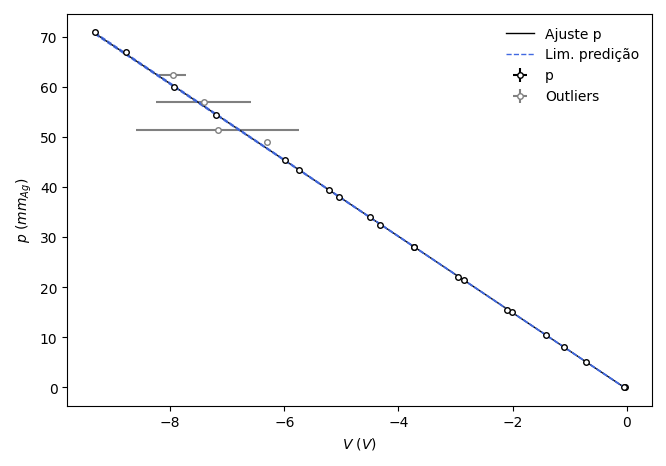

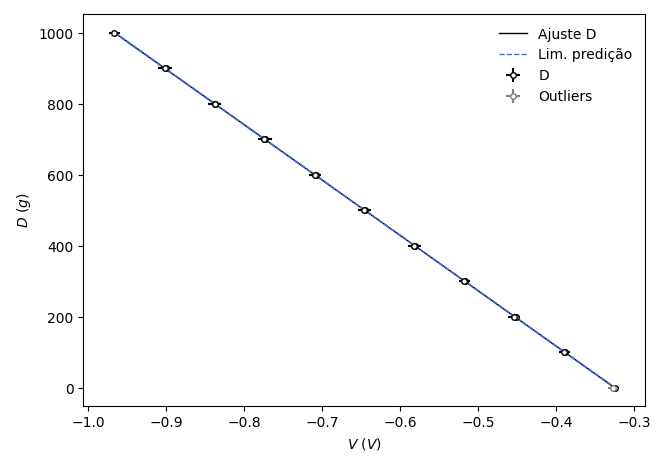

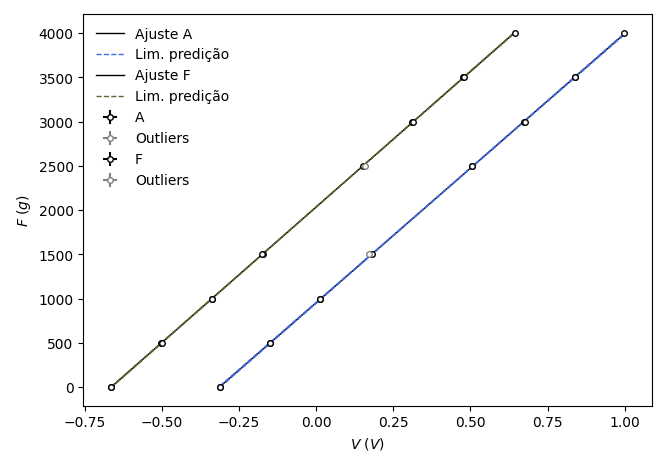

In [100]:
fig, ax = results['Transdutor'].p.calib_model.plot_calibration(figsize = figsize_hor, boundslabel = 'Lim. predição', linelabel = 'Ajuste p', markerlabel = 'p', xlabel = r'$V\ (V)$', ylabel = r'$p\ (mm_{Ag})$', title = '', markeredgewidth = 1)

fig.tight_layout()
if save:
    fig.savefig(pasta_res + f'Calib_p.eps', format = 'eps')

fig, ax = results['Balança'].D.calib_model.plot_calibration(figsize = figsize_hor, boundslabel = 'Lim. predição', linelabel = 'Ajuste D', markerlabel = 'D', xlabel = r'$V\ (V)$', ylabel = r'$D\ (g)$', title = '', markeredgewidth = 1)

fig.tight_layout()
if save:
    fig.savefig(pasta_res + f'Calib_D.eps', format = 'eps')

fig, ax = results['Balança'].A.calib_model.plot_calibration(figsize = figsize_hor, boundslabel = 'Lim. predição', linelabel = 'Ajuste A', markerlabel = 'A', xlabel = r'$V\ (V)$', ylabel = r'$A\ (g)$', title = '', markeredgewidth = 1)

ax = results['Balança'].F.calib_model.plot_calibration(ax = ax, figsize = figsize_hor, boundslabel = 'Lim. predição', linelabel = 'Ajuste F', markerlabel = 'F', xlabel = r'$V\ (V)$', ylabel = r'$F\ (g)$', title = '', markeredgewidth = 1, boundscolor = 'darkolivegreen')

fig.tight_layout()
if save:
    fig.savefig(pasta_res + f'Calib_A_F.eps', format = 'eps')


## $C_l,C_d, C_m \times \alpha$

In [101]:
save = False
coef = 'C_l'

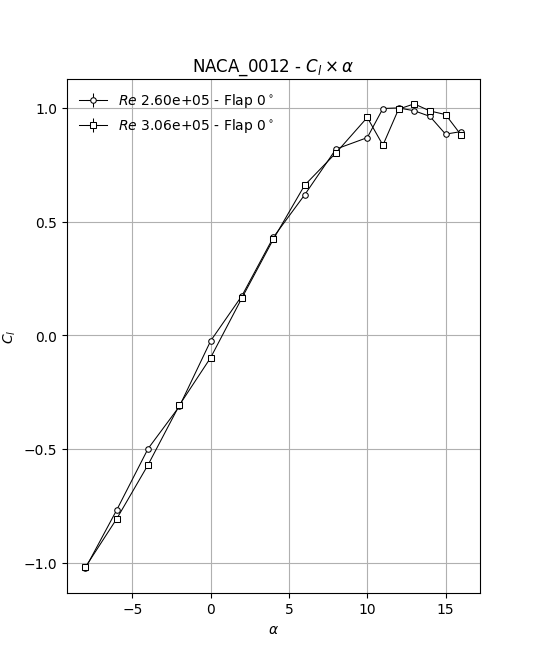

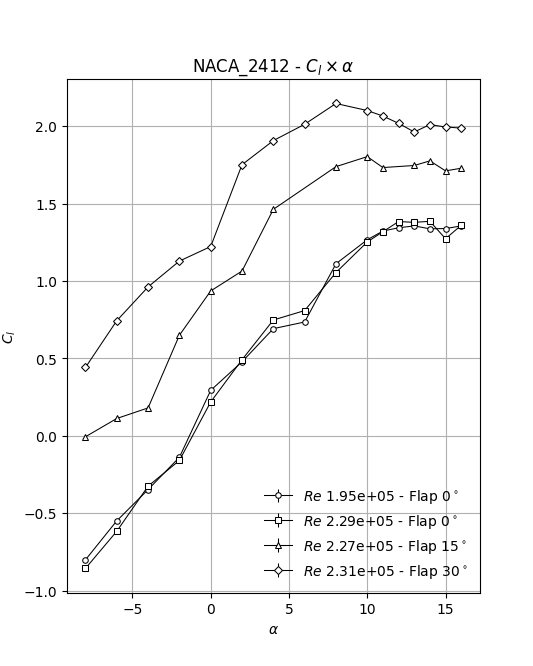

In [102]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    fig, ax = plt.subplots(figsize = figsize_ver)

    i = 0
    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            mask = perf.prop[flap][vel]['alpha'] <= 16 

            label = fr'$Re$ {perf.prop[flap][vel]['Re_0'].x[0]:.2e} - Flap ${flap}^\circ$'
            if vel in [25, 35]:
                ax.errorbar(perf.prop[flap][vel]['alpha'][mask].x, perf.prop[flap][vel][coef][mask].x, xerr = perf.prop[flap][vel]['alpha'][mask].sigma_x, yerr = perf.prop[flap][vel][coef][mask].sigma_x, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                i += 1

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(fr'${coef}$')
    ax.set_title(fr'{perfil} - ${coef} \times \alpha$')
    ax.legend(frameon = False)
    ax.grid()

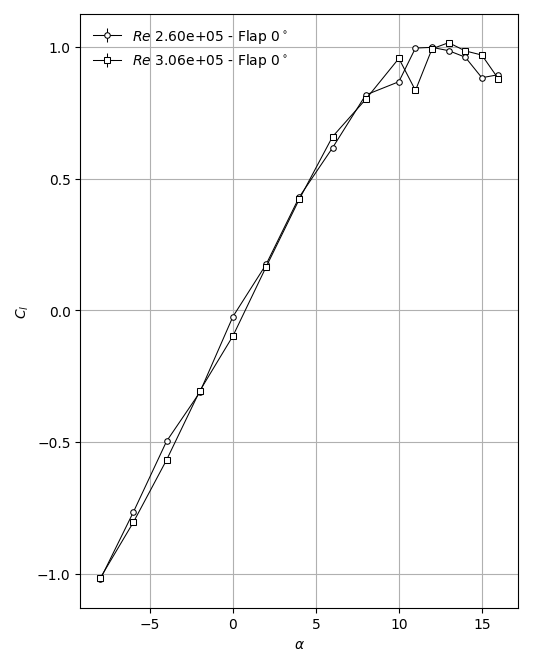

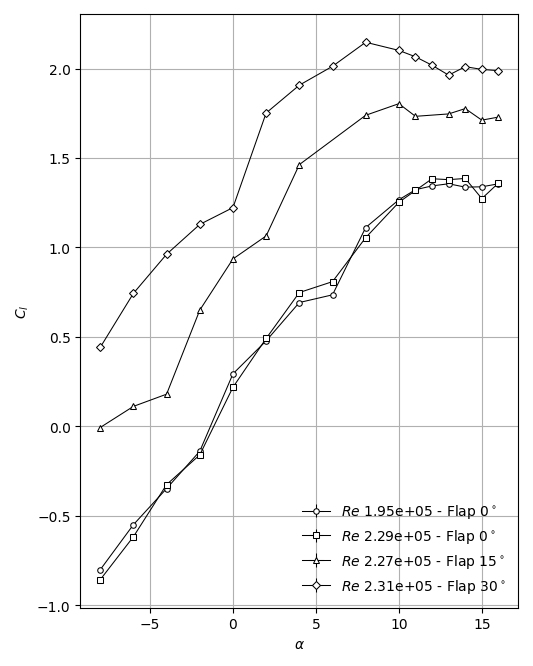

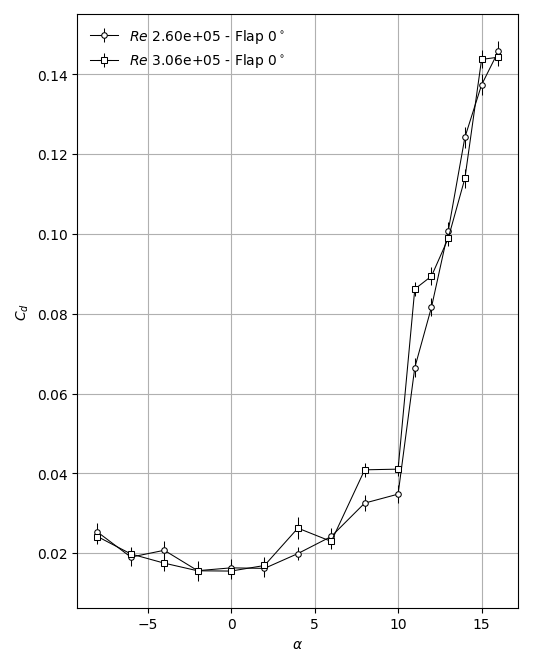

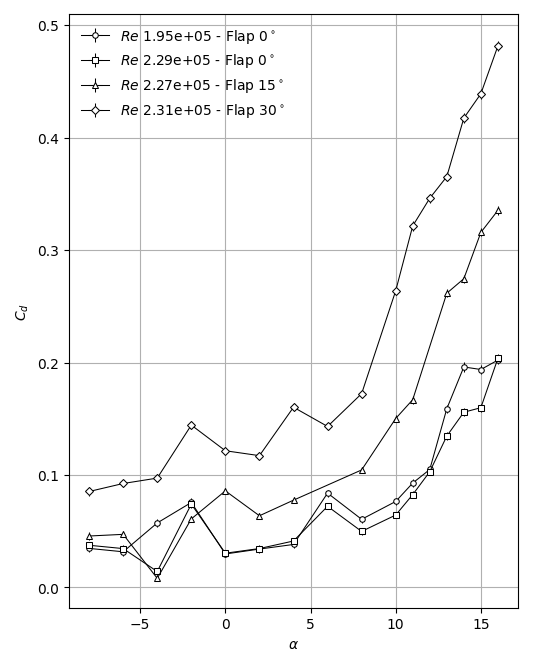

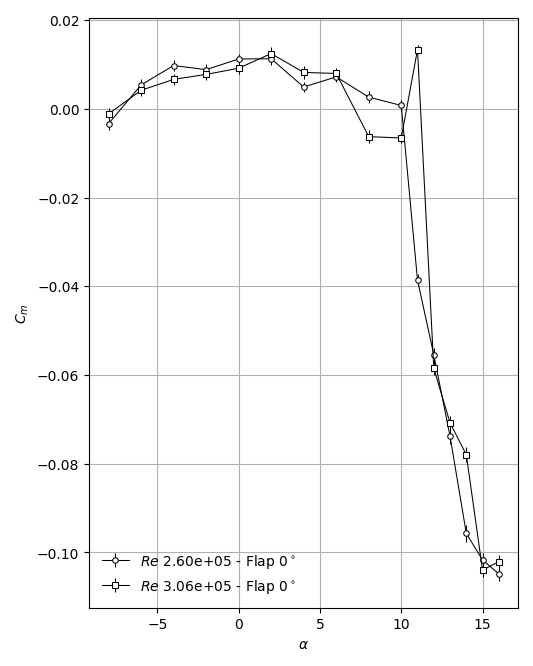

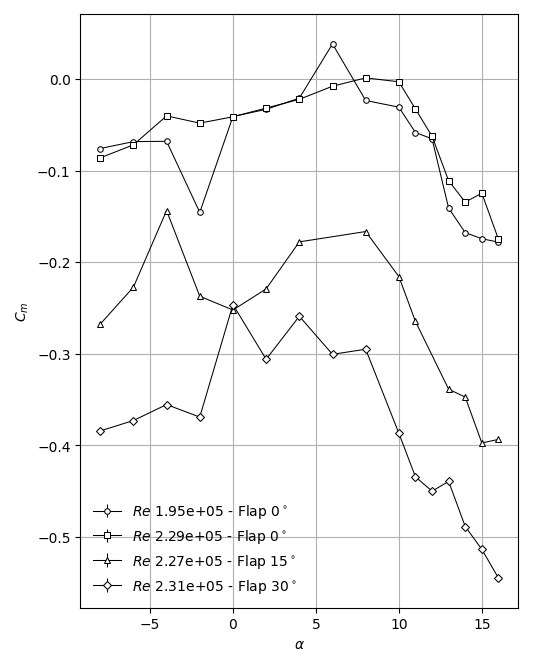

In [103]:
for coef in ['C_l', 'C_d', 'C_m']:
    for perfil in ['NACA_0012', 'NACA_2412']:
        perf = results[perfil]

        fig, ax = plt.subplots(figsize = figsize_ver)

        i = 0
        for flap in perf.keys.keys():
            for vel in perf.keys[flap]:
                mask = perf.prop[flap][vel]['alpha'] <= 16 

                label = fr'$Re$ {perf.prop[flap][vel]['Re_0'].x[0]:.2e} - Flap ${flap}^\circ$'
                if vel in [25, 35]:
                    ax.errorbar(perf.prop[flap][vel]['alpha'][mask].x, perf.prop[flap][vel][coef][mask].x, xerr = perf.prop[flap][vel]['alpha'][mask].sigma_x, yerr = perf.prop[flap][vel][coef][mask].sigma_x, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                    i += 1

        ax.set_xlabel(r'$\alpha$')
        ax.set_ylabel(fr'${coef}$')
        ax.legend(frameon = False)
        ax.grid()

        fig.tight_layout()
        if save:
            fig.savefig(pasta_res + f'{perfil}_{coef}_x_alpha.eps', format = 'eps')


In [104]:
results['NACA_0012'].set_alpha_e(10, 0, 25)
results['NACA_0012'].set_alpha_e(10, 0, 35)

results['NACA_2412'].set_alpha_e(12, 0, 25)
results['NACA_2412'].set_alpha_e(12, 0, 35)
results['NACA_2412'].set_alpha_e(10, 15, 35)
results['NACA_2412'].set_alpha_e(8, 30, 35)

## $C_l \times \alpha$ linear

In [105]:
save = False

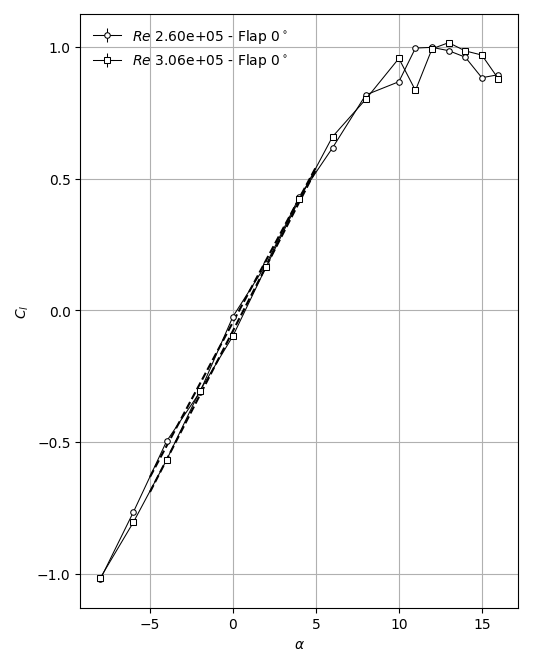

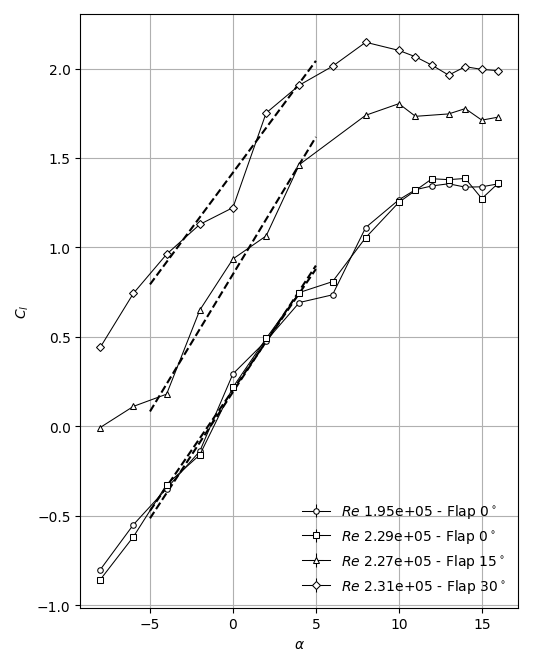

In [106]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    fig, ax = plt.subplots(figsize = figsize_ver)

    i = 0
    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            # mask = (-perf.prop[flap][vel]['alpha_e'] <= perf.prop[flap][vel]['alpha']) & (perf.prop[flap][vel]['alpha'] <= perf.prop[flap][vel]['alpha_e'])
            mask = perf.prop[flap][vel]['alpha'] <= 16
            alpha_0 = perf.prop[flap][vel]['alpha'] == 0

            label = fr'$Re$ {perf.prop[flap][vel]['Re'][alpha_0].x[0]:.2e} - Flap ${flap}^\circ$'
            if vel in [25, 35] and flap in [0, 15, 30]:
                ax.errorbar(perf.prop[flap][vel]['alpha'][mask].x, perf.prop[flap][vel]['C_l'][mask].x, xerr = perf.prop[flap][vel]['alpha'][mask].sigma_x, yerr = perf.prop[flap][vel]['C_l'][mask].sigma_x, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                
                x, y = perf.C_l_linear(100, flap, vel)
                ax.plot(x*TO_DEG, y, '--', color = 'black')

                i += 1

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(fr'$C_l$')
    # ax.set_title(fr'{perfil} - $C_l \times \alpha$')
    ax.legend(frameon = False)
    ax.grid()

    fig.tight_layout()
    if save:
        fig.savefig(pasta_res + f'{perfil}_C_l_x_alpha_lin.eps', format = 'eps')


## $C_l \times \alpha$ parabólico

In [107]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    perf.get_lift_parabola()

In [108]:
save = False

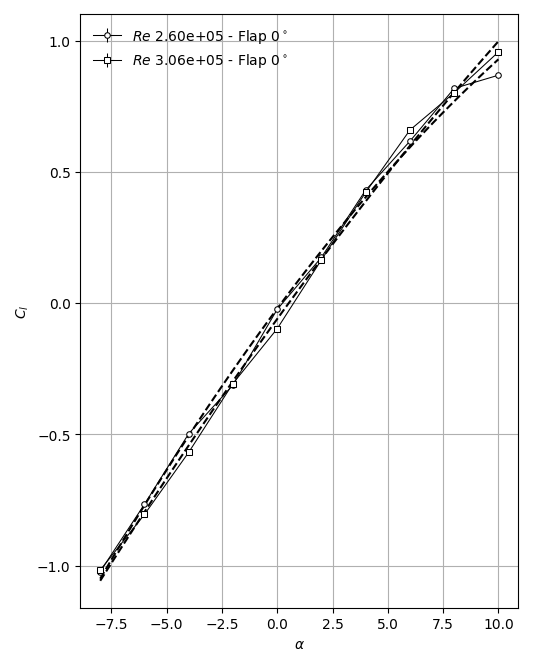

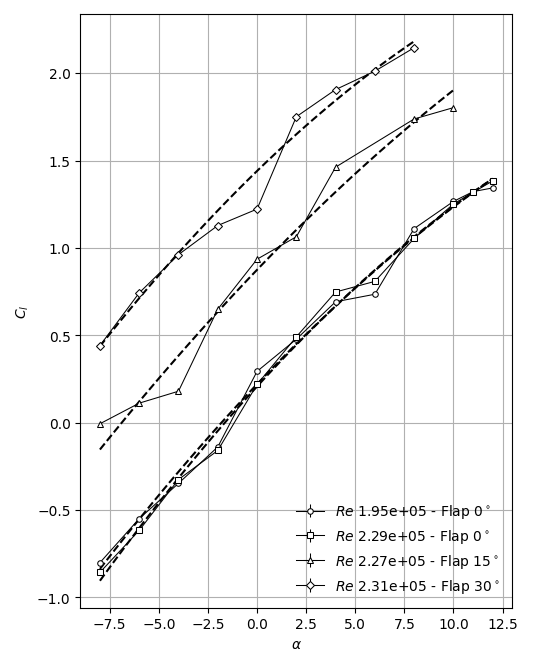

In [109]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    fig, ax = plt.subplots(figsize = figsize_ver)

    i = 0
    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            mask = (-perf.prop[flap][vel]['alpha_e'] <= perf.prop[flap][vel]['alpha']) & (perf.prop[flap][vel]['alpha'] <= perf.prop[flap][vel]['alpha_e'])
            alpha_0 = perf.prop[flap][vel]['alpha'] == 0

            label = fr'$Re$ {perf.prop[flap][vel]['Re'][alpha_0].x[0]:.2e} - Flap ${flap}^\circ$'
            if vel in [25, 35] and flap in [0, 15, 30]:
                ax.errorbar(perf.prop[flap][vel]['alpha'][mask].x, perf.prop[flap][vel]['C_l'][mask].x, xerr = perf.prop[flap][vel]['alpha'][mask].sigma_x, yerr = perf.prop[flap][vel]['C_l'][mask].sigma_x, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                
                x, y = perf.C_l_parabola(100, flap, vel)
                ax.plot(x*TO_DEG, y, '--', color = 'black')

                i += 1

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(fr'$C_l$')
    # ax.set_title(fr'{perfil} - $C_l \times \alpha$')
    ax.legend(frameon = False)
    ax.grid()

    fig.tight_layout()
    if save:
        fig.savefig(pasta_res + f'{perfil}_C_l_x_alpha_par.eps', format = 'eps')


## $C_l \times \alpha$ exp

In [147]:
results['NACA_0012'].set_alpha_e(14, 0, 25)
results['NACA_0012'].set_alpha_e(14, 0, 35)

results['NACA_2412'].set_alpha_e(14, 0, 25)
results['NACA_2412'].set_alpha_e(14, 0, 35)
results['NACA_2412'].set_alpha_e(12, 15, 35)
results['NACA_2412'].set_alpha_e(10, 30, 35)

In [148]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    perf.get_lift_exp()

In [149]:
save = False
alpha_lim = 30

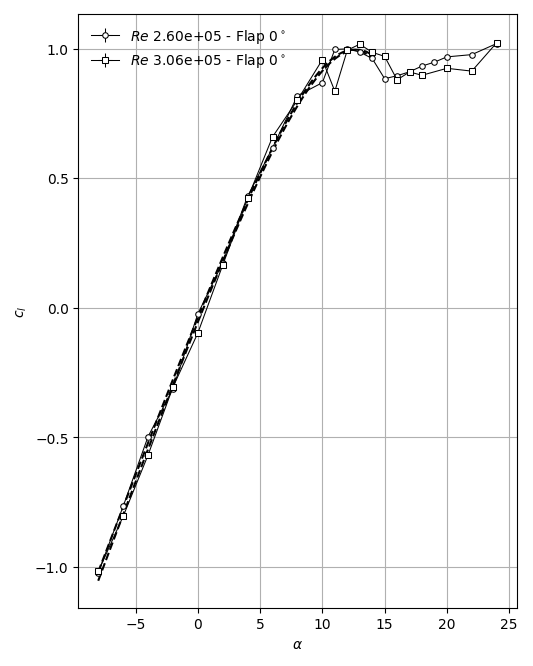

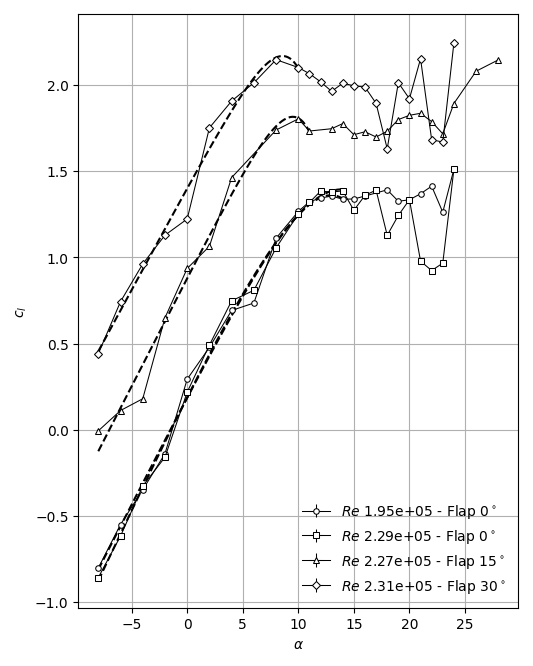

In [151]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    fig, ax = plt.subplots(figsize = figsize_ver)

    i = 0
    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            # mask = (-perf.prop[flap][vel]['alpha_e'] <= perf.prop[flap][vel]['alpha']) & (perf.prop[flap][vel]['alpha'] <= perf.prop[flap][vel]['alpha_e'])
            mask = perf.prop[flap][vel]['alpha'] <= alpha_lim
            alpha_0 = perf.prop[flap][vel]['alpha'] == 0

            label = fr'$Re$ {perf.prop[flap][vel]['Re'][alpha_0].x[0]:.2e} - Flap ${flap}^\circ$'
            if vel in [25, 35] and flap in [0, 15, 30]:
                ax.errorbar(perf.prop[flap][vel]['alpha'][mask].x, perf.prop[flap][vel]['C_l'][mask].x, xerr = perf.prop[flap][vel]['alpha'][mask].sigma_x, yerr = perf.prop[flap][vel]['C_l'][mask].sigma_x, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                
                x, y = perf.C_l_exp(100, flap, vel)
                ax.plot(x*TO_DEG, y.x, '--', color = 'black')

                i += 1

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(fr'$c_l$')
    # ax.set_title(fr'{perfil} - $c_l \times \alpha$')
    ax.legend(frameon = False)
    ax.grid()

    fig.tight_layout()
    if save:
        fig.savefig(pasta_res + f'{perfil}_C_l_x_alpha_exp.eps', format = 'eps')


## $C_d \times \alpha$

In [114]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    perf.get_drag_parabola()

In [115]:
save = False

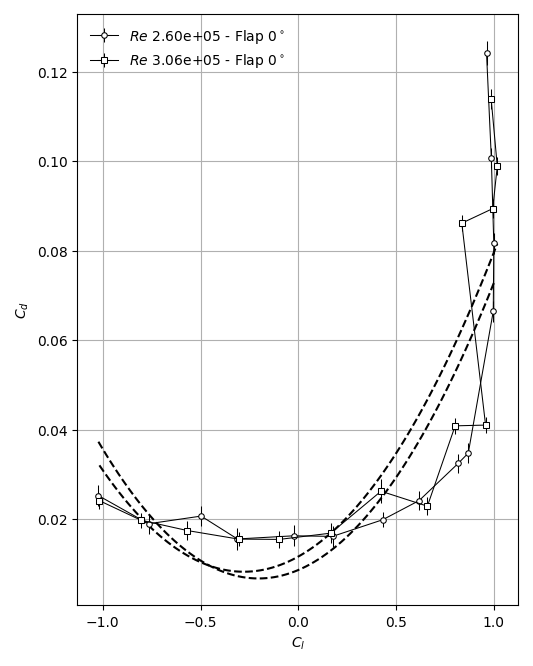

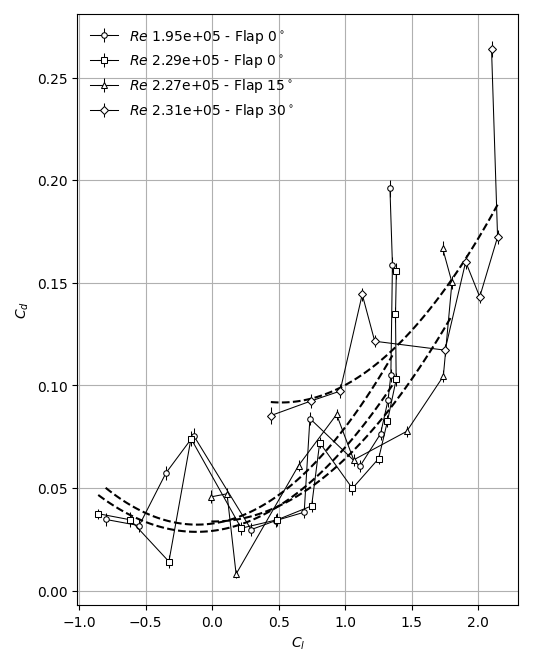

In [116]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    fig, ax = plt.subplots(figsize = figsize_ver)

    i = 0
    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            mask = (-perf.prop[flap][vel]['alpha_e'] <= perf.prop[flap][vel]['alpha']) & (perf.prop[flap][vel]['alpha'] <= perf.prop[flap][vel]['alpha_e'])
            alpha_0 = perf.prop[flap][vel]['alpha'] == 0

            label = fr'$Re$ {perf.prop[flap][vel]['Re'][alpha_0].x[0]:.2e} - Flap ${flap}^\circ$'
            if vel in [25, 35] and flap in [0, 15, 30]:
                ax.errorbar(perf.prop[flap][vel]['C_l'][mask].x, perf.prop[flap][vel]['C_d'][mask].x, xerr = perf.prop[flap][vel]['C_l'][mask].sigma_x, yerr = perf.prop[flap][vel]['C_d'][mask].sigma_x, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                
                x, y = perf.C_d(100, flap, vel)
                ax.plot(x, y, '--', color = 'black')

                i += 1

    ax.set_xlabel(r'$C_l$')
    ax.set_ylabel(fr'$C_d$')
    # ax.set_title(fr'{perfil} - $C_d \times C_l$')
    ax.legend(frameon = False)
    ax.grid()

    fig.tight_layout()
    if save:
        fig.savefig(pasta_res + f'{perfil}_C_d_x_C_l.eps', format = 'eps')


## $Re$

In [117]:
save = False

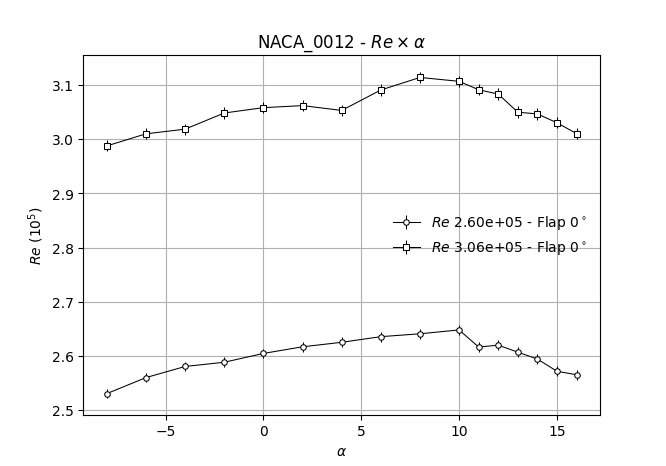

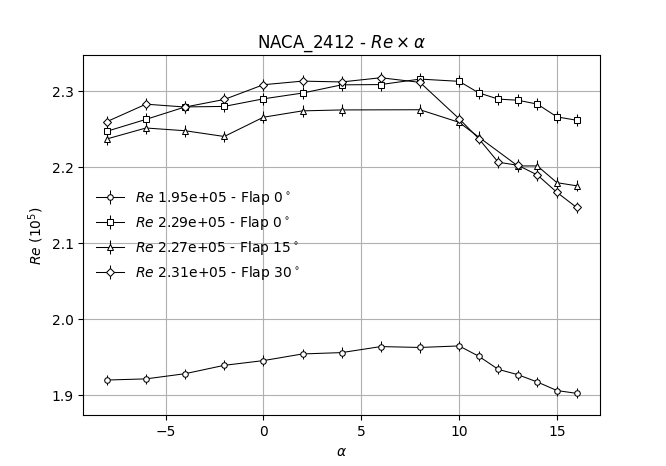

In [118]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    fig, ax = plt.subplots(figsize = figsize_hor)

    i = 0
    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            mask = perf.prop[flap][vel]['alpha'] <= 16 
            alpha_0 = perf.prop[flap][vel]['alpha'] == 0

            label = fr'$Re$ {perf.prop[flap][vel]['Re'][alpha_0].x[0]:.2e} - Flap ${flap}^\circ$'
            if vel in [25, 35]:
                ax.errorbar(perf.prop[flap][vel]['alpha'][mask].x, perf.prop[flap][vel]['Re'][mask].x/1e5, xerr = perf.prop[flap][vel]['alpha'][mask].sigma_x, yerr = perf.prop[flap][vel]['Re'][mask].sigma_x/1e5, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                i += 1


    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(fr'$Re\ (10^5)$')
    ax.set_title(fr'{perfil} - $Re \times \alpha$')
    ax.legend(frameon = False)
    ax.grid()

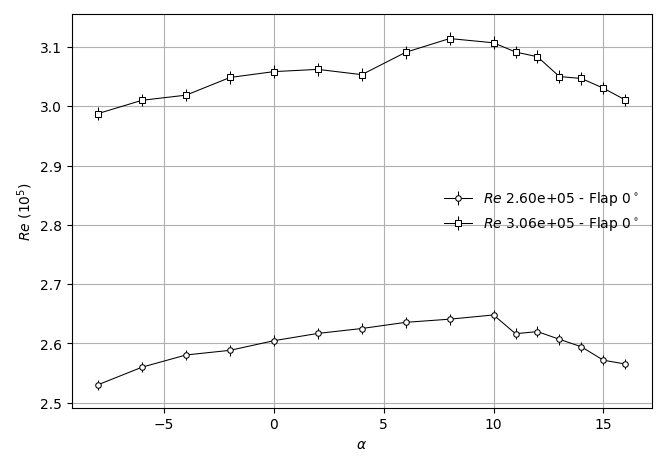

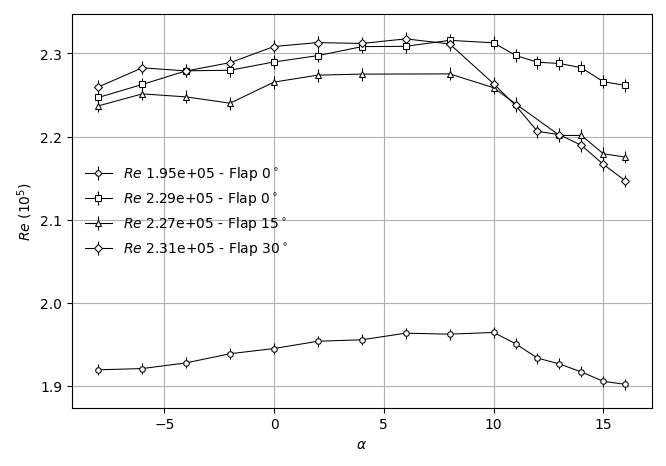

In [119]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    fig, ax = plt.subplots(figsize = figsize_hor)

    i = 0
    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            mask = perf.prop[flap][vel]['alpha'] <= 16 
            alpha_0 = perf.prop[flap][vel]['alpha'] == 0

            label = fr'$Re$ {perf.prop[flap][vel]['Re'][alpha_0].x[0]:.2e} - Flap ${flap}^\circ$'
            if vel in [25, 35]:
                ax.errorbar(perf.prop[flap][vel]['alpha'][mask].x, perf.prop[flap][vel]['Re'][mask].x/1e5, xerr = perf.prop[flap][vel]['alpha'][mask].sigma_x, yerr = perf.prop[flap][vel]['Re'][mask].sigma_x/1e5, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                i += 1


    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(fr'$Re\ (10^5)$')
    # ax.set_title(fr'{perfil} - $Re \times \alpha$')
    ax.legend(frameon = False)
    ax.grid()

    fig.tight_layout()
    if save == True:
        fig.savefig(pasta_res + f'{perfil}_Re_x_alpha.eps', format = 'eps')

## $X_{cp}$

In [120]:
save = False

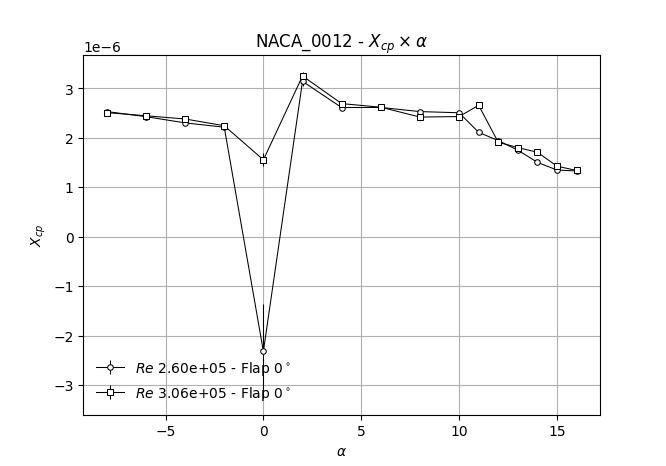

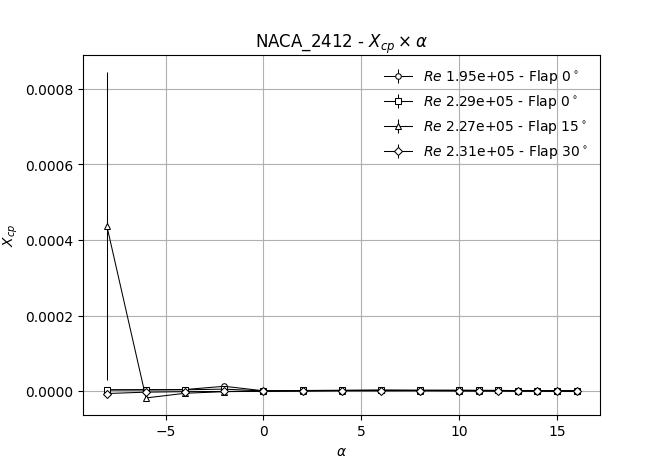

In [121]:
for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    fig, ax = plt.subplots(figsize = figsize_hor)

    i = 0
    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            mask = perf.prop[flap][vel]['alpha'] <= 16 
            alpha_0 = perf.prop[flap][vel]['alpha'] == 0

            label = fr'$Re$ {perf.prop[flap][vel]['Re'][alpha_0].x[0]:.2e} - Flap ${flap}^\circ$'
            if vel in [25, 35]:
                ax.errorbar(perf.prop[flap][vel]['alpha'][mask].x, perf.prop[flap][vel]['X_cp'][mask].x/1e5, xerr = perf.prop[flap][vel]['alpha'][mask].sigma_x, yerr = perf.prop[flap][vel]['X_cp'][mask].sigma_x/1e5, marker = markers[i], markersize = markersize, color = 'black', markeredgecolor = 'black', markerfacecolor = markerfacecolor, markeredgewidth = markeredgewidth, linewidth = linewidth, label = label)
                i += 1


    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(fr'$X_{{cp}}$')
    ax.set_title(fr'{perfil} - $X_{{cp}} \times \alpha$')
    ax.legend(frameon = False)
    ax.grid()

## $X_{ca}, C_{l_\alpha}, \alpha_0, Re$

In [122]:
print('X_ca')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            X_ca = perf.prop[flap][vel]['X_ca']
            print(f'{perfil} - Flap {flap} - vel {vel}: {X_ca}')

X_ca
NACA_0012 - Flap 0 - vel 15: 
0.25217931864664594 ± 0.004897397477509338
NACA_0012 - Flap 0 - vel 25: 
0.2540861263955183 ± 0.003440228172188419
NACA_0012 - Flap 0 - vel 35: 
0.2465658157054808 ± 0.002670947135652653
NACA_2412 - Flap 0 - vel 15: 
0.23697507245121863 ± 0.13742902085027117
NACA_2412 - Flap 0 - vel 25: 
0.169206107420112 ± 0.04570447443916501
NACA_2412 - Flap 0 - vel 35: 
0.22829208220039077 ± 0.006293113748243327
NACA_2412 - Flap 15 - vel 35: 
0.2801864151673418 ± 0.04623742722317789
NACA_2412 - Flap 30 - vel 35: 
0.1732015369015359 ± 0.050529744786414525


In [142]:
print('C_l_alpha')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    perf.get_C_l_alpha(delta_alpha = [-5, 5])

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            C_l_alpha = perf.prop[flap][vel]['C_l_alpha']
            print(f'{perfil} - Flap {flap} - vel {vel}: {C_l_alpha}')

C_l_alpha
NACA_0012 - Flap 0 - vel 15: 
7.030149132494395 ± 0.12443043759260916
NACA_0012 - Flap 0 - vel 25: 
6.7444787715353565 ± 0.22460628467262375
NACA_0012 - Flap 0 - vel 35: 
7.017317984936587 ± 0.1561606372801842
NACA_2412 - Flap 0 - vel 15: 
5.072824249955666 ± 1.7919341844008503
NACA_2412 - Flap 0 - vel 25: 
7.740749120884468 ± 0.703799714611513
NACA_2412 - Flap 0 - vel 35: 
8.093129712420167 ± 0.45926974931043424
NACA_2412 - Flap 15 - vel 35: 
8.788365236446646 ± 0.7481355675978651
NACA_2412 - Flap 30 - vel 35: 
7.158990544389215 ± 0.9432054311859873


In [146]:
print('alpha_0')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    perf.get_C_l_alpha(delta_alpha = [-5, 5])

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            alpha_0 = perf.prop[flap][vel]['alpha_0']*TO_DEG
            print(f'{perfil} - Flap {flap} - vel {vel}: {alpha_0}')

alpha_0
NACA_0012 - Flap 0 - vel 15: 
0.3029898218289948 ± 0.051929274402129175
NACA_0012 - Flap 0 - vel 25: 
0.37612787126010905 ± 0.09887898275226897
NACA_0012 - Flap 0 - vel 35: 
0.6337869031757548 ± 0.06261363423723067
NACA_2412 - Flap 0 - vel 15: 
-1.5039321088089312 ± 1.1561911016250965
NACA_2412 - Flap 0 - vel 25: 
-1.5072882920231367 ± 0.28170130039406566
NACA_2412 - Flap 0 - vel 35: 
-1.3628929977327866 ± 0.1746936503366173
NACA_2412 - Flap 15 - vel 35: 
-5.543902192810615 ± 0.54288447791531
NACA_2412 - Flap 30 - vel 35: 
-11.350223023620588 ± 1.5486679392252527


In [125]:
print('Re_0')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    perf.get_C_l_alpha(delta_alpha = [-10,10])

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            Re_0 = perf.prop[flap][vel]['Re_0']
            print(f'{perfil} - Flap {flap} - vel {vel}: {Re_0}')

Re_0
NACA_0012 - Flap 0 - vel 15: 
198722.35383850915 ± 685.5320730048038
NACA_0012 - Flap 0 - vel 25: 
260467.04694302243 ± 896.4491068949586
NACA_0012 - Flap 0 - vel 35: 
305842.2534414427 ± 1051.106634040993
NACA_2412 - Flap 0 - vel 15: 
152070.24362571342 ± 528.2016205959336
NACA_2412 - Flap 0 - vel 25: 
194518.35698250955 ± 672.9349602792295
NACA_2412 - Flap 0 - vel 35: 
228970.26032623384 ± 791.6766972725973
NACA_2412 - Flap 15 - vel 35: 
226549.21370782153 ± 782.5381668727156
NACA_2412 - Flap 30 - vel 35: 
230825.782069101 ± 796.6320110645989


In [126]:
print('c')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        c = perf.prop[flap]['c']
        print(f'{perfil} - Flap {flap} - vel {vel}: {c}')

c
NACA_0012 - Flap 0 - vel 35: 
0.2029 ± 0.0001
NACA_2412 - Flap 0 - vel 35: 
0.1524 ± 0.0001
NACA_2412 - Flap 15 - vel 35: 
0.1524 ± 0.0001
NACA_2412 - Flap 30 - vel 35: 
0.1524 ± 0.0001


# Geral

In [127]:
results['Balança'].F.calib_model.model.summary()

c:\Users\Gustavo\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            WLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.233e+05
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           4.70e-30
Time:                        18:19:53   Log-Likelihood:                -44.095
No. Observations:                  14   AIC:                             92.19
Df Residuals:                      12   BIC:                             93.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2035.3240      1.587   1282.218      0.000    2031.865    2038.782
x1          3066.4520      3.606    850.461      0.000    3058.596    3074.308
==============================================================================
Omnibus:                        0.450   Durbin-Watson:                   1.685
Prob(Omnibus):                  0.799   Jarque-Bera (JB):                0.521
Skew:                           0.109   Prob(JB):                        0.771
Kurtosis:                       2.080   Cond. No.                         2.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [128]:
print('C_d_0')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            C_d_0 = perf.prop[flap][vel]['C_d_0']
            print(f'{perfil} - Flap {flap} - vel {vel}: {C_d_0}')

C_d_0
NACA_0012 - Flap 0 - vel 15: 
0.012775975552403323 ± 0.0011482624493322573
NACA_0012 - Flap 0 - vel 25: 
0.008675582804109912 ± 0.008816936851637574
NACA_0012 - Flap 0 - vel 35: 
0.011680983627103956 ± 0.009780265518915483
NACA_2412 - Flap 0 - vel 15: 
0.019904711263566667 ± 0.0166341069300719
NACA_2412 - Flap 0 - vel 25: 
0.03261693563294301 ± 0.014317137170581865
NACA_2412 - Flap 0 - vel 35: 
0.02905222851800505 ± 0.010762374249371482
NACA_2412 - Flap 15 - vel 35: 
0.03365701074450181 ± 0.016520747687482996
NACA_2412 - Flap 30 - vel 35: 
0.1013656486769279 ± 0.0708242646115147


In [129]:
print('k_1')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            k_1 = perf.prop[flap][vel]['k_1']
            print(f'{perfil} - Flap {flap} - vel {vel}: {k_1}')

k_1
NACA_0012 - Flap 0 - vel 15: 
0.006173772021128307 ± 0.0010592254264531714
NACA_0012 - Flap 0 - vel 25: 
0.018566267432228993 ± 0.008604993705416002
NACA_0012 - Flap 0 - vel 35: 
0.02433142550900759 ± 0.008262807518601544
NACA_2412 - Flap 0 - vel 15: 
-0.003994088214369217 ± 0.02467671545901356
NACA_2412 - Flap 0 - vel 25: 
0.008772605953001974 ± 0.01847322073109063
NACA_2412 - Flap 0 - vel 35: 
0.007772433731177599 ± 0.01365628429087121
NACA_2412 - Flap 15 - vel 35: 
-0.000662543242366323 ± 0.05118488210685977
NACA_2412 - Flap 30 - vel 35: 
-0.03755960499231037 ± 0.12199954851044655


In [130]:
print('k_2')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            k_2 = perf.prop[flap][vel]['k_2']
            print(f'{perfil} - Flap {flap} - vel {vel}: {k_2}')

k_2
NACA_0012 - Flap 0 - vel 15: 
0.017280490291920247 ± 0.0020900749323558695
NACA_0012 - Flap 0 - vel 25: 
0.04556431592865441 ± 0.01507481558381441
NACA_0012 - Flap 0 - vel 35: 
0.04360360141257805 ± 0.015675197068394296
NACA_2412 - Flap 0 - vel 15: 
0.03508854948328073 ± 0.028952914970222923
NACA_2412 - Flap 0 - vel 25: 
0.03813294145073224 ± 0.020362054629916037
NACA_2412 - Flap 0 - vel 35: 
0.032937704298162535 ± 0.014606788498525654
NACA_2412 - Flap 15 - vel 35: 
0.0312362829614993 ± 0.0275597774038052
NACA_2412 - Flap 30 - vel 35: 
0.03630972927622528 ± 0.04476212490695857


In [131]:
print('C_l_alpha_exp')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            C_l_alpha_exp = perf.prop[flap][vel]['C_l_alpha_exp']
            print(f'{perfil} - Flap {flap} - vel {vel}: {C_l_alpha_exp}')

C_l_alpha_exp
NACA_0012 - Flap 0 - vel 15: 
6.84246539275813 ± 0.44528544273254567
NACA_0012 - Flap 0 - vel 25: 
6.770896259836286 ± 0.45157283732540443
NACA_0012 - Flap 0 - vel 35: 
6.84627055011729 ± 1.0315408701545288
NACA_2412 - Flap 0 - vel 15: 
5.418574757318755 ± 52.7601699752188
NACA_2412 - Flap 0 - vel 25: 
6.996016248867743 ± 0.725091434228436
NACA_2412 - Flap 0 - vel 35: 
7.282562375843845 ± 1.3522325649444942
NACA_2412 - Flap 15 - vel 35: 
7.126389570323117 ± 0.792681544515942
NACA_2412 - Flap 30 - vel 35: 
6.672747914678729 ± 0.8884198411598758


In [143]:
print('C_l_alpha')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    perf.get_C_l_alpha(delta_alpha = [-5, 5])

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            C_l_alpha = perf.prop[flap][vel]['C_l_alpha']
            print(f'{perfil} - Flap {flap} - vel {vel}: {C_l_alpha}')

C_l_alpha
NACA_0012 - Flap 0 - vel 15: 
7.030149132494395 ± 0.12443043759260916
NACA_0012 - Flap 0 - vel 25: 
6.7444787715353565 ± 0.22460628467262375
NACA_0012 - Flap 0 - vel 35: 
7.017317984936587 ± 0.1561606372801842
NACA_2412 - Flap 0 - vel 15: 
5.072824249955666 ± 1.7919341844008503
NACA_2412 - Flap 0 - vel 25: 
7.740749120884468 ± 0.703799714611513
NACA_2412 - Flap 0 - vel 35: 
8.093129712420167 ± 0.45926974931043424
NACA_2412 - Flap 15 - vel 35: 
8.788365236446646 ± 0.7481355675978651
NACA_2412 - Flap 30 - vel 35: 
7.158990544389215 ± 0.9432054311859873


In [133]:
print('alpha_0_exp')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            alpha_0_exp = perf.prop[flap][vel]['alpha_0_exp']*TO_DEG
            print(f'{perfil} - Flap {flap} - vel {vel}: {alpha_0_exp}')

alpha_0_exp
NACA_0012 - Flap 0 - vel 15: 
-5.074548902746223e-07 ± 0.24389590487884125
NACA_0012 - Flap 0 - vel 25: 
-0.030819708386068553 ± 0.28519222731783495
NACA_0012 - Flap 0 - vel 35: 
-0.0014069249875854493 ± 0.6674084008419211
NACA_2412 - Flap 0 - vel 15: 
-1.7112291037321372 ± 70.69023289569186
NACA_2412 - Flap 0 - vel 25: 
-1.5911467141738453 ± 0.4451070709648238
NACA_2412 - Flap 0 - vel 35: 
-1.8586741899781813 ± 0.9009659756138657
NACA_2412 - Flap 15 - vel 35: 
-7.010150344999112 ± 0.8437914195429951
NACA_2412 - Flap 30 - vel 35: 
-11.83977403856669 ± 1.373589195065723


In [134]:
print('alpha_e_exp')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            alpha_e_exp = perf.prop[flap][vel]['alpha_e_exp']*TO_DEG
            print(f'{perfil} - Flap {flap} - vel {vel}: {alpha_e_exp}')

alpha_e_exp
NACA_0012 - Flap 0 - vel 15: 
11.624180912630322 ± 5.259004652498928
NACA_0012 - Flap 0 - vel 25: 
12.492029732999816 ± 3.8710184003534907
NACA_0012 - Flap 0 - vel 35: 
12.768582711246241 ± 8.172616771786805
NACA_2412 - Flap 0 - vel 15: 
22.25585997767594 ± 1047.9497645471502
NACA_2412 - Flap 0 - vel 25: 
12.957021394584261 ± 9.716816412864713
NACA_2412 - Flap 0 - vel 35: 
13.886511477428094 ± 10.835292508772882
NACA_2412 - Flap 15 - vel 35: 
9.506862552778788 ± 11.868937492091533
NACA_2412 - Flap 30 - vel 35: 
8.574852774092742 ± 11.20307042201785


In [135]:
print('C_l_max_exp')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            C_l_max_exp = perf.prop[flap][vel]['C_l_max_exp']
            print(f'{perfil} - Flap {flap} - vel {vel}: {C_l_max_exp}')

C_l_max_exp
NACA_0012 - Flap 0 - vel 15: 
0.9688055950673325 ± 1.1392472160526559
NACA_0012 - Flap 0 - vel 25: 
0.9962273442544525 ± 0.8473945053094135
NACA_0012 - Flap 0 - vel 35: 
0.9964957343361464 ± 1.834104815700613
NACA_2412 - Flap 0 - vel 15: 
1.5055454384770421 ± 188.0711222515519
NACA_2412 - Flap 0 - vel 25: 
1.3604942214738889 ± 2.115258905817791
NACA_2412 - Flap 0 - vel 35: 
1.3944144175691677 ± 2.6034897386130695
NACA_2412 - Flap 15 - vel 35: 
1.815362728339087 ± 2.5782332200683777
NACA_2412 - Flap 30 - vel 35: 
2.167847257267196 ± 2.295628367107116


In [136]:
print('a_0_exp')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            a_0_exp = perf.prop[flap][vel]['a_0_exp']
            print(f'{perfil} - Flap {flap} - vel {vel}: {a_0_exp}')

a_0_exp
NACA_0012 - Flap 0 - vel 15: 
6.393377184557789e-08 ± 0.03072821926724543
NACA_0012 - Flap 0 - vel 25: 
0.003912556429100022 ± 0.036204744842211374
NACA_0012 - Flap 0 - vel 35: 
0.00018323799160767585 ± 0.08692330720682263
NACA_2412 - Flap 0 - vel 15: 
0.17961602800454232 ± 7.387975575586594
NACA_2412 - Flap 0 - vel 25: 
0.20069116712826668 ± 0.05397723702464508
NACA_2412 - Flap 0 - vel 35: 
0.2595198746956628 ± 0.12312159657654775
NACA_2412 - Flap 15 - vel 35: 
0.8808159042389527 ± 0.058337277825158525
NACA_2412 - Flap 30 - vel 35: 
1.404276909854505 ± 0.06156433731953398


In [137]:
print('a_1_exp')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            a_1_exp = perf.prop[flap][vel]['a_1_exp']
            print(f'{perfil} - Flap {flap} - vel {vel}: {a_1_exp}')

a_1_exp
NACA_0012 - Flap 0 - vel 15: 
7.218642218861149 ± 0.23879942142440166
NACA_0012 - Flap 0 - vel 25: 
7.273688890435466 ± 0.2989232718109699
NACA_0012 - Flap 0 - vel 35: 
7.4622056315818925 ± 0.6464921180869095
NACA_2412 - Flap 0 - vel 15: 
6.013946534171843 ± 23.01035007431448
NACA_2412 - Flap 0 - vel 25: 
7.226710622957672 ± 0.5558765796929914
NACA_2412 - Flap 0 - vel 35: 
7.999999999999999 ± 0.7957422205827394
NACA_2412 - Flap 15 - vel 35: 
7.199137159289792 ± 0.7235651385083703
NACA_2412 - Flap 30 - vel 35: 
6.795665182481522 ± 0.7299392045883575


In [138]:
print('a_2_exp')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            a_2_exp = perf.prop[flap][vel]['a_2_exp']
            print(f'{perfil} - Flap {flap} - vel {vel}: {a_2_exp}')

a_2_exp
NACA_0012 - Flap 0 - vel 15: 
-0.02583258896299822 ± 0.02461567418719896
NACA_0012 - Flap 0 - vel 25: 
-0.04102878582046736 ± 0.026617154430233162
NACA_0012 - Flap 0 - vel 35: 
-0.05502722763986576 ± 0.06891308490626383
NACA_2412 - Flap 0 - vel 15: 
-0.09999999999999998 ± 7.303356636133527
NACA_2412 - Flap 0 - vel 25: 
-0.01514607954130748 ± 0.02973531382772604
NACA_2412 - Flap 0 - vel 35: 
-0.0721050130922702 ± 0.10485049175041283
NACA_2412 - Flap 15 - vel 35: 
-0.002627084671834419 ± 0.011505919146925532
NACA_2412 - Flap 30 - vel 35: 
-0.00458457187343786 ± 0.018522880548117383


In [139]:
print('a_3_exp')

for perfil in ['NACA_0012', 'NACA_2412']:
    perf = results[perfil]

    for flap in perf.keys.keys():
        for vel in perf.keys[flap]:
            a_3_exp = perf.prop[flap][vel]['a_3_exp']
            print(f'{perfil} - Flap {flap} - vel {vel}: {a_3_exp}')

a_3_exp
NACA_0012 - Flap 0 - vel 15: 
14.562103188412243 ± 4.373337462895769
NACA_0012 - Flap 0 - vel 25: 
12.254630999788438 ± 2.2026745983696463
NACA_0012 - Flap 0 - vel 35: 
11.193278452908539 ± 4.108950664576361
NACA_2412 - Flap 0 - vel 15: 
5.953717768530891 ± 190.64737148667422
NACA_2412 - Flap 0 - vel 25: 
15.231292920439373 ± 7.121326036768508
NACA_2412 - Flap 0 - vel 35: 
9.94989936744168 ± 4.535557388445421
NACA_2412 - Flap 15 - vel 35: 
27.69137582302485 ± 21.807543813073785
NACA_2412 - Flap 30 - vel 35: 
26.811067902534585 ± 21.64689828258721
